### 타이타닉 탑승자 데이터
| 컬럼명              | 설명                                                        |
| ---------------- | --------------------------------------------------------- |
| **survived**     | 생존 여부 (0 = 사망, 1 = 생존)                                    |
| **pclass**       | 선실 등급 (1 = 1등석, 2 = 2등석, 3 = 3등석)                         |
| **sex**          | 성별 ('male', 'female')                                     |
| **age**          | 나이                                                        |
| **sibsp**        | 함께 탑승한 형제/배우자 수 (siblings/spouses)                        |
| **parch**        | 함께 탑승한 부모/자녀 수 (parents/children)                         |
| **fare**         | 승객 요금                                                     |
| **embarked**     | 탑승 항구 코드 (C = Cherbourg, Q = Queenstown, S = Southampton) |
| **class**        | `pclass`와 동일하지만 문자열로 표시 ('First', 'Second', 'Third')      |
| **who**          | 승객 구분 ('man', 'woman', 'child')                           |
| **adult\_male**  | 성인 남성 여부 (True/False)                                     |
| **deck**         | 객실이 위치한 갑판 (A\~G 등, 일부 결측값 존재)                            |
| **embark\_town** | 탑승 도시명 (예: 'Cherbourg', 'Southampton')                    |
| **alive**        | 생존 여부 문자열 ('yes' 또는 'no')                                 |
| **alone**        | 혼자 탑승 여부 (True/False)                                     |

※ survived와 alive은 같은 컬럼이므로 alive제외하고 훈련해야함

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,confusion_matrix,  classification_report

In [2]:
titanic = sns.load_dataset('titanic')
print(titanic.columns)
print(titanic.info() )
print(titanic.head(2))

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null  

In [4]:
titanic.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
titanic.isnull()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
887,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False
889,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [6]:
titanic.isnull().sum(axis=1)

0      1
1      0
2      1
3      0
4      1
      ..
886    1
887    0
888    2
889    0
890    1
Length: 891, dtype: int64

In [7]:
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [8]:
# titanic['age'].fillna(titanic['age'].mean(), inplace=True)

# pandas 3.0부터 변경됨
titanic.fillna( {'age':titanic['age'].mean()}, inplace=True)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.000000,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.000000,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.000000,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.000000,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.000000,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.000000,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.000000,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,29.699118,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.000000,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [9]:
titanic['age'].isnull().sum()

np.int64(0)

In [10]:
titanic['embarked']

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: embarked, Length: 891, dtype: str

In [11]:
titanic['embarked'].isnull().sum()

np.int64(2)

In [12]:
titanic['embarked'].value_counts()

embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [13]:
titanic.fillna({'embarked':'N'}, inplace=True)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.000000,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.000000,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.000000,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.000000,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.000000,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.000000,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.000000,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,29.699118,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.000000,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [14]:
#titanic['deck'] = titanic['deck'].cat.add_categories('N')      # 옛날 버전에서는 카테고리에 추가를 해줬어야하지만 지금은 안해도됨.
titanic['deck'] = titanic['deck'].cat.add_categories('N')
titanic.fillna( {'deck':'N'}, inplace=True)
titanic['deck'].isnull().sum()

np.int64(0)

In [15]:
titanic['deck'].value_counts()

deck
N    688
C     59
B     47
D     33
E     32
A     15
F     13
G      4
Name: count, dtype: int64

In [16]:
print( titanic['deck'].dtype.name == 'category' )

True


In [17]:
print( titanic['deck'].dtype )

category


In [18]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     891 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         891 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [19]:
titanic.fillna( {'embark_town':'N'}, inplace=True )
titanic['embark_town'].isnull().sum()

np.int64(0)

In [56]:
# 남,여 탑승수
titanic['sex'].value_counts()

sex
male      577
female    314
Name: count, dtype: int64

In [ ]:
# 생존 여부      0(사망), 1(생존)
titanic['survived'].value_counts()

survived
0    549
1    342
Name: count, dtype: int64

In [60]:
print(dir(titanic) )

['T', '_AXIS_LEN', '_AXIS_ORDERS', '_AXIS_TO_AXIS_NUMBER', '_HANDLED_TYPES', '__abs__', '__add__', '__and__', '__annotations__', '__array__', '__array_priority__', '__array_ufunc__', '__arrow_c_stream__', '__bool__', '__class__', '__contains__', '__copy__', '__dataframe__', '__deepcopy__', '__delattr__', '__delitem__', '__dict__', '__dir__', '__divmod__', '__doc__', '__eq__', '__finalize__', '__floordiv__', '__format__', '__ge__', '__getattr__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__iadd__', '__iand__', '__ifloordiv__', '__imod__', '__imul__', '__init__', '__init_subclass__', '__invert__', '__ior__', '__ipow__', '__isub__', '__iter__', '__itruediv__', '__ixor__', '__le__', '__len__', '__lt__', '__matmul__', '__mod__', '__module__', '__mul__', '__ne__', '__neg__', '__new__', '__or__', '__pandas_priority__', '__pos__', '__pow__', '__radd__', '__rand__', '__rdivmod__', '__reduce__', '__reduce_ex__', '__repr__', '__rfloordiv__', '__rmatmul__', '__rmod_

In [67]:
# 성별 별 생존율
print( titanic.groupby(['sex'])['survived'].sum() )
print('--------------------------------------------------------')
print( titanic.groupby(['sex'])['survived'].mean() )
print('--------------------------------------------------------')
print( titanic.groupby(['sex'])['survived'].value_counts() )

sex
female    233
male      109
Name: survived, dtype: int64
--------------------------------------------------------
sex
female    0.742038
male      0.188908
Name: survived, dtype: float64
--------------------------------------------------------
sex     survived
female  1           233
        0            81
male    0           468
        1           109
Name: count, dtype: int64


In [68]:
print( titanic.groupby(['sex','survived']).count() )

                 pclass  age  sibsp  parch  fare  embarked  class  who  \
sex    survived                                                          
female 0             81   81     81     81    81        81     81   81   
       1            233  233    233    233   233       233    233  233   
male   0            468  468    468    468   468       468    468  468   
       1            109  109    109    109   109       109    109  109   

                 adult_male  deck  embark_town  alive  alone  
sex    survived                                               
female 0                 81    81           81     81     81  
       1                233   233          233    233    233  
male   0                468   468          468    468    468  
       1                109   109          109    109    109  


In [69]:
print( titanic.groupby(['sex','survived'])['survived'].count() )

sex     survived
female  0            81
        1           233
male    0           468
        1           109
Name: survived, dtype: int64


<Axes: xlabel='sex', ylabel='survived'>

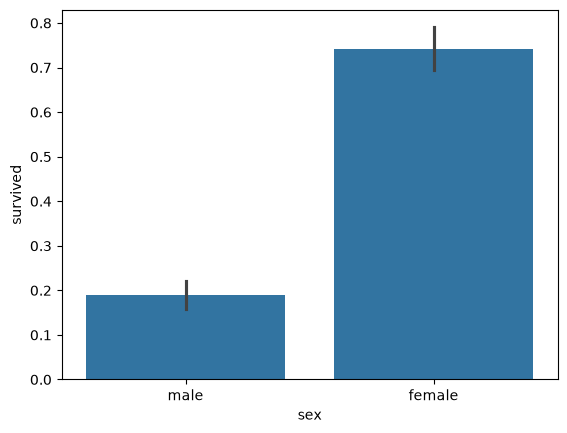

In [70]:
sns.barplot(data=titanic, x='sex', y='survived')

<Axes: xlabel='pclass', ylabel='survived'>

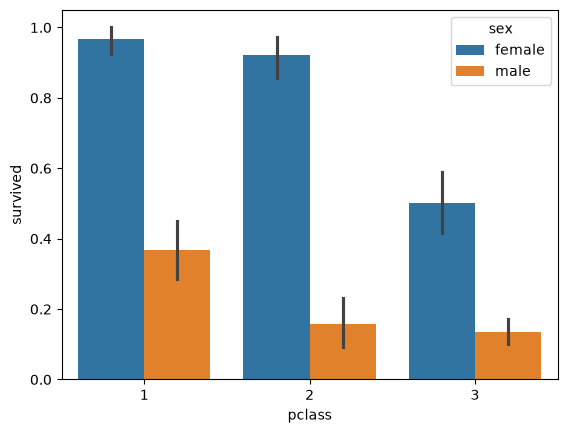

In [71]:
# 선실등급별 남여 생존여부
sns.barplot(data=titanic, x='pclass', y='survived', hue='sex')

### 객실 등급별 성별에 따른 생존 확률  

- 여성의 경우 일등실, 이등실에 따른 생존 확률의 차이는 크지 않으나, 삼등실의 경우 생존 확률이 상대적으로 많이 떨어짐을 알 수 있다.  
- 남성의 경우는 일등실의 생존 확률이 이, 삼등실의 생존 확률보다 월등이 높다.  
- 제임스 카메론의 영화인 '타이타닉'에서도 나왔듯이 바다에서 사고가 날 경우 여성과 아이들, 그리고 노약자가 제일 먼저 구조대상이다. 그리고 부자나 유명인이 다음 구조 대상이다. 삼등실에 탄 많은 가난한 이는 타이타닉 호와 운명을 함께 했다.

In [ ]:
#X_train, X_test, y_train, y_test = train_test_split(titanic.loc[:, 'pclass':'alone'], titanic['survived'], random_state=11)

# string을 int로 변경하기 위해 전부 주석처리.

In [ ]:
#model = LogisticRegression(max_iter=1000)

In [3]:
import platform
import sklearn

if platform.system() == 'Windows' :
    sklearn.set_config(display='text')

# model = LogisticRegression(max_iter=10000)
# model.fit(X_train, y_train)

# 문자열은 학습 안되기 때문에 sex, embarked, who 등을 바꿔야함.

In [20]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     891 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         891 non-null    category
 12  embark_town  891 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


# info()에서 나온 int가 아닌것들의 type을 int로 바꿔야함
category는 labelIncoder로 변경할것임.

## LabelEncoder()로 인코딩
사이킷런 등에서 제공됨.

In [23]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

titanic_df1 = titanic.copy()        # 딥카피로 가져옴

In [24]:
titanic['who'].value_counts()

who
man      537
woman    271
child     83
Name: count, dtype: int64

In [26]:
# 변환할 컬럼 목록 (str, category)
label_cols = ['sex', 'embarked', 'class', 'who', 'deck', 'embark_town']

# le.fit_transform : 레이블 인코더로 변환을 하고 핏트랜스폼 하라.
for col in label_cols :
    titanic_df1[col] = le.fit_transform(titanic_df1[col])   

In [27]:
titanic_df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    int64  
 3   age          891 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     891 non-null    int64  
 8   class        891 non-null    int64  
 9   who          891 non-null    int64  
 10  adult_male   891 non-null    bool   
 11  deck         891 non-null    int64  
 12  embark_town  891 non-null    int64  
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(10), str(1)
memory usage: 92.4 KB


In [29]:
titanic_df1[label_cols].head()

,sex,embarked,class,who,deck,embark_town
0,1,3,2,1,7,3
1,0,0,0,2,2,0
2,0,3,2,2,7,3
3,0,3,0,2,2,3
4,1,3,2,1,7,3


In [33]:
print(titanic['sex'].head() )

0      male
1    female
2    female
3    female
4      male
Name: sex, dtype: str


In [34]:
print( titanic_df1['sex'].head() )

0    1
1    0
2    0
3    0
4    1
Name: sex, dtype: int64


LableEncoder로 변경하면, 단순 숫자로만 변경할 뿐, 그 숫자가 어떠한 의미를 갖고있지는 않다.
단어에 번호를 매김.

In [35]:
titanic_df1['sex'].value_counts()

sex
1    577
0    314
Name: count, dtype: int64

In [36]:
titanic_df1['deck'].value_counts()

deck
7    688
2     59
1     47
3     33
4     32
0     15
5     13
6      4
Name: count, dtype: int64

# One Hot Encoding

LabelEncoder 는 단어에 번호를 매기는 반면,
oneHotEncoding 은

## OneHotEncoding(sparse_output=False, handle_unknown='ignore')

남 : 1  0
여 : 0  1


ex) deck

A : 0000001
B : 0000010
C : 0000100

=> 원핫인코딩은 공간 낭비가 심하다. (deck가 7개면, 그걸 위해서 7개의 공간을 만들어야함.)

OneHotEncoder(sparse_output=False, handle_unknown='ignore')

| 파라미터                      | 설명                                                                            |
| ------------------------- | ----------------------------------------------------------------------------- |
| `sparse_output=False`     | 반환값을 **희소 행렬(sparse matrix)** 대신 **NumPy 배열**로 반환. <br> → DataFrame으로 변환하기 쉬움 |
| `handle_unknown='ignore'` | 학습 시 보지 못한 **새로운 범주가 등장해도 에러 없이 무시**. <br> → 안정적인 예측 및 인코딩 수행                 |

In [53]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

titanic_df2 = titanic.copy()

# 변환할 컬럼 목록
ohe_cols = ['sex', 'embarked', 'class', 'who', 'deck', 'embark_town']

ohe_result = pd.DataFrame(index=titanic_df2.index)
print('ohe_result:', ohe_result.head())

print('ohe_result_len:', len(ohe_result) )

ohe_result: Empty DataFrame
Columns: []
Index: [0, 1, 2, 3, 4]
ohe_result_len: 891


In [54]:
for col in ohe_cols :
    encoded = ohe.fit_transform(titanic_df2[[col]])
    #print(encoded)

    col_names = ohe.get_feature_names_out( [col] )      # 인덱스의 피쳐를 가져와줌. 0번은 여자, 1번은 남자.
    print(col_names)

    encoded_df = pd.DataFrame(encoded, columns=col_names, index=titanic_df2.index)      # == ohe_result.index
    # ohe_result에, encoded_df 를 계속 각각  추가해줘야함. 근데 둘다 데이터프레임임. 그럼 어떻게 넣어아햘까? 길게 넣어야할듯. concat 사옹하여 연결 선택.

    ohe_result = pd.concat( [ohe_result, encoded_df], axis=1)
    #print(ohe_result.head())
    #break


['sex_female' 'sex_male']
['embarked_C' 'embarked_N' 'embarked_Q' 'embarked_S']
['class_First' 'class_Second' 'class_Third']
['who_child' 'who_man' 'who_woman']
['deck_A' 'deck_B' 'deck_C' 'deck_D' 'deck_E' 'deck_F' 'deck_G' 'deck_N']
['embark_town_Cherbourg' 'embark_town_N' 'embark_town_Queenstown'
 'embark_town_Southampton']


In [55]:
ohe_result.head()

,sex_female,sex_male,embarked_C,embarked_N,embarked_Q,embarked_S,class_First,class_Second,class_Third,who_child,...,deck_C,deck_D,deck_E,deck_F,deck_G,deck_N,embark_town_Cherbourg,embark_town_N,embark_town_Queenstown,embark_town_Southampton
0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [56]:
print(len(ohe_result.columns))

24


기존에 만든건 없애고, 새로 만든 원핫인코딩 집어넣기

In [57]:
titanic_df2 = pd.concat( [ titanic_df2.drop(columns = ohe_cols) ] ) # 컬럼이 이거인걸 지워라
titanic_df2

,survived,pclass,age,sibsp,parch,fare,adult_male,alive,alone
0,0,3,22.000000,1,0,7.2500,True,no,False
1,1,1,38.000000,1,0,71.2833,False,yes,False
2,1,3,26.000000,0,0,7.9250,False,yes,True
3,1,1,35.000000,1,0,53.1000,False,yes,False
4,0,3,35.000000,0,0,8.0500,True,no,True
...,...,...,...,...,...,...,...,...,...
886,0,2,27.000000,0,0,13.0000,True,no,True
887,1,1,19.000000,0,0,30.0000,False,yes,True
888,0,3,29.699118,1,2,23.4500,False,no,False
889,1,1,26.000000,0,0,30.0000,True,yes,True


In [63]:
titanic_df2.drop(columns=['alive'], inplace=True, errors='ignore')
titanic_df2

,survived,pclass,age,sibsp,parch,fare,adult_male,alone
0,0,3,22.000000,1,0,7.2500,True,False
1,1,1,38.000000,1,0,71.2833,False,False
2,1,3,26.000000,0,0,7.9250,False,True
3,1,1,35.000000,1,0,53.1000,False,False
4,0,3,35.000000,0,0,8.0500,True,True
...,...,...,...,...,...,...,...,...
886,0,2,27.000000,0,0,13.0000,True,True
887,1,1,19.000000,0,0,30.0000,False,True
888,0,3,29.699118,1,2,23.4500,False,False
889,1,1,26.000000,0,0,30.0000,True,True


In [65]:
titanic_df2 = pd.concat( [titanic_df2, ohe_result], axis=1)

print( titanic_df2.columns )
titanic_df2.head()

Index(['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'adult_male',
       'alone', 'sex_female', 'sex_male', 'embarked_C', 'embarked_N',
       'embarked_Q', 'embarked_S', 'class_First', 'class_Second',
       'class_Third', 'who_child', 'who_man', 'who_woman', 'deck_A', 'deck_B',
       'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 'deck_N',
       'embark_town_Cherbourg', 'embark_town_N', 'embark_town_Queenstown',
       'embark_town_Southampton', 'sex_female', 'sex_male', 'embarked_C',
       'embarked_N', 'embarked_Q', 'embarked_S', 'class_First', 'class_Second',
       'class_Third', 'who_child', 'who_man', 'who_woman', 'deck_A', 'deck_B',
       'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 'deck_N',
       'embark_town_Cherbourg', 'embark_town_N', 'embark_town_Queenstown',
       'embark_town_Southampton'],
      dtype='str')


,survived,pclass,age,sibsp,parch,fare,adult_male,alone,sex_female,sex_male,...,deck_C,deck_D,deck_E,deck_F,deck_G,deck_N,embark_town_Cherbourg,embark_town_N,embark_town_Queenstown,embark_town_Southampton
0,0,3,22.0,1,0,7.2500,True,False,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,1,1,38.0,1,0,71.2833,False,False,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,1,3,26.0,0,0,7.9250,False,True,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,1,1,35.0,1,0,53.1000,False,False,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0,3,35.0,0,0,8.0500,True,True,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


원핫인코더로 하면, 컬럼의 갯수가, 컬럼 안에 있던 고유값 (피쳐) 만큼 컬럼이 생성돼서 갯수가 무수히 많아짐.

# 순서가 중요한 것들은 => LabelEncoder    ( deck 같은 것)
# 순서가 중요하지 않은 것들은 => OneHotEncoder
# 이진으로 분류되는 것들은 굳이 OneHotEncoder로 변환하여 메모리 공간을 차지할 필요 X. (비효율)

| 컬럼명           | 타입       | 인코딩 방식        | 설명                      |
| ------------- | -------- | ------------- | ----------------------- |
| `sex`         | str   | OneHotEncoder | 남/여 → 순서 의미 없음          |
| `embarked`    | str   | OneHotEncoder | 탑승 항구 (순서 없음)           |
| `class`       | category | LabelEncoder  | 1등, 2등, 3등 (순서 있음)      |
| `who`         | str   | OneHotEncoder | man/woman/child (순서 없음) |
| `deck`        | category | OneHotEncoder | 갑판 A\~G,N (순서 없음)       |
| `embark_town` | str   | OneHotEncoder | 도시명 (순서 없음)             |
| `alive`       | str   | LabelEncoder  | yes/no → 이진             |
| `adult_male`  | bool     | LabelEncoder  | True/False → 1/0        |
| `alone`       | bool     | LabelEncoder  | True/False → 1/0        |


필요에 맞게 다시 만들기

In [ ]:
titanic_df3 = titanic.copy()

titanic_df3.drop(columns=['alive'], inplace=True, errors='ignore')

# 1. LabelEncoder 적용할 컬럼
label_cols = ['class', 'adult_male', 'alnoe']
le = LabelEncoder()

for col in label_cols :
    titanic_df3[col] = le.fit_transform(titanic_df3[col])

# 2. OneHotEncoder 적용할 컬럼
ohe_cols = ['sex', 'embarked', 'who', 'deck', 'embark_town']
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# 결과 저장 DataFrame
ohe_result = pd.DataFrame(index=titanic_df3.index)

for col in ohe_cols :
    encoded = ohe.fit_transform(ti)

In [ ]:
titanic_df3 = titanic.copy()

# 1. LabelEncoder 적용할 컬럼
label_cols = ['class', 'adult_male', 'alone']
le = LabelEncoder()

for col in label_cols:
    titanic_df3[col] = le.fit_transform(titanic_df3[col])

# 2. OneHotEncoder 적용할 컬럼
ohe_cols = ['sex', 'embarked', 'who', 'deck', 'embark_town']
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# 결과를 저장할 DataFrame
ohe_result = pd.DataFrame(index=titanic_df3.index)

for col in ohe_cols:
    #encoded 타입은 ndarray
    encoded = ohe.fit_transform(titanic_df3[[col]])
    col_names = ohe.get_feature_names_out([col])
    encoded_df = pd.DataFrame(encoded, columns=col_names, index=titanic_df3.index)
    ohe_result = pd.concat([ohe_result, encoded_df], axis=1)

# 기존 원본 컬럼 삭제 후 병합
titanic_df3 = pd.concat([titanic_df3.drop(columns=ohe_cols), ohe_result], axis=1)
print(titanic_df3.info())


# sklearn의 make transfomer ? 를 이용하여 인코딩 해보기

데이터 전처리를 단계별로 진행할 때 범주형 변수와 연속형 변수를 나누고, 개별적으로 전처리하는 과정을 했다.
sklean-learn에서 제공하는 make_column_transformer와 ColumnTransformer을 이용해서 범주형변수와 연속형 변수를 한번에  전처리를 할 수 있도록 제공해준다.

make_columns_transformer를 이용한 인코딩  
- make_column_transformer((전처리 객체, 전처리를 적용할 컬럼), (전처리 객체, 전처리를 적용할 컬럼))
- LabelEncoder는 1차원만 처리 가능하므로 make_column_transformer에 직접 쓸 수 없습니다. 대신 **OrdinalEncoder**를 사용한다.

# make_columns_transformer

In [109]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline

titanic_df4 = titanic.copy()
titanic_df4.drop(columns=['alive'], inplace=True)

In [116]:
len(titanic.columns)

15

In [117]:
print(titanic_df4.columns)
len(titanic_df4.columns)

Index(['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'sex_female',
       'sex_male', 'embarked_C', 'embarked_N', 'embarked_Q', 'embarked_S',
       'who_child', 'who_man', 'who_woman', 'deck_A', 'deck_B', 'deck_C',
       'deck_D', 'deck_E', 'deck_F', 'deck_G', 'deck_N',
       'embark_town_Cherbourg', 'embark_town_N', 'embark_town_Queenstown',
       'embark_town_Southampton', 'class', 'adult_male', 'alone'],
      dtype='str')


30

In [111]:
# 인코딩 지정
onehot_cols = ['sex', 'embarked', 'who', 'deck',  'embark_town']
ordinal_cols = ['class', 'adult_male', 'alone']

# make_column_transformer
# remainder='passthrough' : 나머지 컬럼은 그대로 유지 (예:age, fare 등)
column_transformer = make_column_transformer( ( OneHotEncoder(handle_unknown='ignore', sparse_output=False), onehot_cols ), 
                                             ( OrdinalEncoder(), ordinal_cols ),
                                              remainder='passthrough' )

# 변환 적용
encoded = column_transformer.fit_transform(titanic_df4)

In [112]:
encoded     # df가 아니라 배열로 변환

array([[ 0.    ,  1.    ,  0.    , ...,  1.    ,  0.    ,  7.25  ],
       [ 1.    ,  0.    ,  1.    , ...,  1.    ,  0.    , 71.2833],
       [ 1.    ,  0.    ,  0.    , ...,  0.    ,  0.    ,  7.925 ],
       ...,
       [ 1.    ,  0.    ,  0.    , ...,  1.    ,  2.    , 23.45  ],
       [ 0.    ,  1.    ,  1.    , ...,  0.    ,  0.    , 30.    ],
       [ 0.    ,  1.    ,  0.    , ...,  0.    ,  0.    ,  7.75  ]],
      shape=(891, 30))

In [113]:
# encoded
titanic_df4.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alone'],
      dtype='str')

In [114]:
# encoded
# titanic_df4

# 컬럼 이름 추출
print( dir (column_transformer) )
print('---------------------------------')
print(column_transformer)
print('---------------------------------')

onehot_feature_names = column_transformer.named_transformers_['onehotencoder'].get_feature_names_out(onehot_cols)
print(f'onehot_feature_names : {onehot_feature_names}')

ordinal_feature_names = ordinal_cols
print('---------------------------------')
print(f'onehot_feature_names : {onehot_feature_names}')
print('---------------------------------')
print(f'ordninal_feature_names : {ordinal_feature_names}')

['__abstractmethods__', '__annotations__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setstate__', '__sizeof__', '__sklearn_clone__', '__sklearn_tags__', '__str__', '__subclasshook__', '__weakref__', '_abc_impl', '_add_prefix_for_feature_names_out', '_call_func_on_transformers', '_check_estimators_are_instances', '_columns', '_doc_link_module', '_doc_link_template', '_doc_link_url_param_generator', '_get_class_level_metadata_request_values', '_get_doc_link', '_get_empty_routing', '_get_feature_name_out_for_transformer', '_get_fitted_attr_html', '_get_metadata_request', '_get_param_names', '_get_params', '_get_params_html', '_get_remainder_cols', '_get_remainder_cols_dtype', '_hstack', '_html_repr', '_iter', '_log_me

In [115]:
other_feature_name = [col for col in titanic_df4.columns if col not in onehot_cols + ordinal_cols ]      #  안 바꾼것들도 합치기
print(f'변환 안 준, other_feature_name: {other_feature_name}')

final_feature_names = other_feature_name + list(onehot_feature_names) + ordinal_feature_names
print(f'final_feature_names: {final_feature_names}')

print('onehot_feature_names 는 리스트: ', type( onehot_feature_names) )     # 'numpy.ndarray
print(type( other_feature_name ))   # list
print(type(ordinal_feature_names))  # list

# DataFrame으로 변환
titanic_df4 = pd.DataFrame(encoded, columns= final_feature_names, index=titanic_df4.index)
print(titanic_df4.head())

변환 안 준, other_feature_name: ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
final_feature_names: ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'sex_female', 'sex_male', 'embarked_C', 'embarked_N', 'embarked_Q', 'embarked_S', 'who_child', 'who_man', 'who_woman', 'deck_A', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 'deck_N', 'embark_town_Cherbourg', 'embark_town_N', 'embark_town_Queenstown', 'embark_town_Southampton', 'class', 'adult_male', 'alone']
onehot_feature_names 는 리스트:  <class 'numpy.ndarray'>
<class 'list'>
<class 'list'>
   survived  pclass  age  sibsp  parch  fare  sex_female  sex_male  \
0       0.0     1.0  0.0    0.0    0.0   1.0         0.0       1.0   
1       1.0     0.0  1.0    0.0    0.0   0.0         0.0       0.0   
2       1.0     0.0  0.0    0.0    0.0   1.0         0.0       0.0   
3       1.0     0.0  0.0    0.0    0.0   1.0         0.0       0.0   
4       0.0     1.0  0.0    0.0    0.0   1.0         0.0       1.0   

   embark

In [120]:
feature_names = column_transformer.get_feature_names_out()
print(feature_names)

['onehotencoder__sex_female' 'onehotencoder__sex_male'
 'onehotencoder__embarked_C' 'onehotencoder__embarked_N'
 'onehotencoder__embarked_Q' 'onehotencoder__embarked_S'
 'onehotencoder__who_child' 'onehotencoder__who_man'
 'onehotencoder__who_woman' 'onehotencoder__deck_A'
 'onehotencoder__deck_B' 'onehotencoder__deck_C' 'onehotencoder__deck_D'
 'onehotencoder__deck_E' 'onehotencoder__deck_F' 'onehotencoder__deck_G'
 'onehotencoder__deck_N' 'onehotencoder__embark_town_Cherbourg'
 'onehotencoder__embark_town_N' 'onehotencoder__embark_town_Queenstown'
 'onehotencoder__embark_town_Southampton' 'ordinalencoder__class'
 'ordinalencoder__adult_male' 'ordinalencoder__alone'
 'remainder__survived' 'remainder__pclass' 'remainder__age'
 'remainder__sibsp' 'remainder__parch' 'remainder__fare']


In [122]:
encoded_df_default = pd.DataFrame(encoded, columns=feature_names)
print(encoded_df_default)

# make transformer에서 생성된 컬럼명 ( 상당히 길음. )

     onehotencoder__sex_female  onehotencoder__sex_male  \
0                          0.0                      1.0   
1                          1.0                      0.0   
2                          1.0                      0.0   
3                          1.0                      0.0   
4                          0.0                      1.0   
..                         ...                      ...   
886                        0.0                      1.0   
887                        1.0                      0.0   
888                        1.0                      0.0   
889                        0.0                      1.0   
890                        0.0                      1.0   

     onehotencoder__embarked_C  onehotencoder__embarked_N  \
0                          0.0                        0.0   
1                          1.0                        0.0   
2                          0.0                        0.0   
3                          0.0                 

In [131]:
column_transformer_ignore = make_column_transformer(
    (OneHotEncoder(handle_unknown='ignore', sparse_output=False), onehot_cols),
    (OrdinalEncoder(), ordinal_cols),
    remainder = 'passthrough',
    verbose_feature_names_out=False     # 접두사 제거 옵션
)

encoded = column_transformer_ignore.fit_transform(titanic_df5)
feature_names = column_transformer_ignore.get_feature_names_out()

encoded_df = pd.DataFrame(encoded, columns=feature_names)
print(f'encoded_df : {encoded_df.columns}')
print(encoded_df)

encoded_df : Index(['sex_female', 'sex_male', 'embarked_C', 'embarked_N', 'embarked_Q',
       'embarked_S', 'who_child', 'who_man', 'who_woman', 'deck_A', 'deck_B',
       'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 'deck_N',
       'embark_town_Cherbourg', 'embark_town_N', 'embark_town_Queenstown',
       'embark_town_Southampton', 'class', 'adult_male', 'alone', 'survived',
       'pclass', 'age', 'sibsp', 'parch', 'fare', 'alive'],
      dtype='str')
    sex_female sex_male embarked_C embarked_N embarked_Q embarked_S who_child  \
0          0.0      1.0        0.0        0.0        0.0        1.0       0.0   
1          1.0      0.0        1.0        0.0        0.0        0.0       0.0   
2          1.0      0.0        0.0        0.0        0.0        1.0       0.0   
3          1.0      0.0        0.0        0.0        0.0        1.0       0.0   
4          0.0      1.0        0.0        0.0        0.0        1.0       0.0   
..         ...      ...        ...        ...    

## ColumnTransformer 를 이용한 인코딩
- make_column_transformer와 별칭 지정 유무만 차이가 있고 결과는 동일하게 나온다.
- ColumnTransformer(transformers=[(별칭, 전처리 객체, 전처리를 적용할 컬럼),(별칭, 전처리 객체, 전처리를 적용할 컬럼)],remainder='passthrough')

In [157]:
from sklearn.compose import ColumnTransformer

titanic_df5 = titanic.copy()
titanic_df5.drop(columns='alive', inplace=True)

In [158]:
titanic_df5.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,N,Southampton,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,N,Southampton,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,N,Southampton,True


In [140]:
'alive' in titanic_df5.columns

False

In [160]:
titanic_df5 = titanic_df5.iloc[:,1:] 

# 2. 인코더 지정
onehot_cols = ['sex', 'embarked', 'who', 'deck', 'embark_town']
ordinal_cols = ['class', 'adult_male', 'alone']

# 3. ColumnTransformer 정의
ct = ColumnTransformer(
transformers=[
('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), onehot_cols),
('ordinal', OrdinalEncoder(), ordinal_cols)
],
remainder='passthrough',
verbose_feature_names_out=False  # 컬럼명에 'onehot__', 'ordinal__' 접두사 제거
)

# 4. 변환 실행
encoded_array = ct.fit_transform(titanic_df5)

# 5. 변환된 컬럼명 추출 및 DataFrame 생성
feature_names = ct.get_feature_names_out()
encoded_df = pd.DataFrame(encoded_array, columns=feature_names)

print(encoded_df.head() )

   sex_female  sex_male  embarked_C  embarked_N  embarked_Q  embarked_S  \
0         0.0       1.0         0.0         0.0         0.0         1.0   
1         1.0       0.0         1.0         0.0         0.0         0.0   
2         1.0       0.0         0.0         0.0         0.0         1.0   
3         1.0       0.0         0.0         0.0         0.0         1.0   
4         0.0       1.0         0.0         0.0         0.0         1.0   

   who_child  who_man  who_woman  deck_A  ...  embark_town_Queenstown  \
0        0.0      1.0        0.0     0.0  ...                     0.0   
1        0.0      0.0        1.0     0.0  ...                     0.0   
2        0.0      0.0        1.0     0.0  ...                     0.0   
3        0.0      0.0        1.0     0.0  ...                     0.0   
4        0.0      1.0        0.0     0.0  ...                     0.0   

   embark_town_Southampton  class  adult_male  alone  pclass   age  sibsp  \
0                      1.0    2.0

In [162]:
print( encoded_df.columns )

Index(['sex_female', 'sex_male', 'embarked_C', 'embarked_N', 'embarked_Q',
       'embarked_S', 'who_child', 'who_man', 'who_woman', 'deck_A', 'deck_B',
       'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 'deck_N',
       'embark_town_Cherbourg', 'embark_town_N', 'embark_town_Queenstown',
       'embark_town_Southampton', 'class', 'adult_male', 'alone', 'pclass',
       'age', 'sibsp', 'parch', 'fare'],
      dtype='str')


In [159]:
target = titanic_df5['survived']
target

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: survived, Length: 891, dtype: int64

In [151]:
print(encoded_df.columns)

Index(['sex_female', 'sex_male', 'embarked_C', 'embarked_N', 'embarked_Q',
       'embarked_S', 'who_child', 'who_man', 'who_woman', 'deck_A', 'deck_B',
       'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 'deck_N',
       'embark_town_Cherbourg', 'embark_town_N', 'embark_town_Queenstown',
       'embark_town_Southampton', 'class', 'adult_male', 'alone', 'age',
       'sibsp', 'parch', 'fare'],
      dtype='str')


In [156]:
# titanic_df5 = pd.concat( [target, encoded_df], axis=1 )
# titanic_df5     # train_test를 할거면, 하면 안되는 것임.

,survived,sex_female,sex_male,embarked_C,embarked_N,embarked_Q,embarked_S,who_child,who_man,who_woman,...,embark_town_N,embark_town_Queenstown,embark_town_Southampton,class,adult_male,alone,age,sibsp,parch,fare
1,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,1.0,2.0,0.0,1.0,26.000000,0.0,0.0,7.9250
2,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,35.000000,1.0,0.0,53.1000
3,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,2.0,1.0,1.0,35.000000,0.0,0.0,8.0500
4,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,2.0,1.0,1.0,29.699118,0.0,0.0,8.4583
5,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,1.0,54.000000,0.0,0.0,51.8625
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
887,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,1.0,2.0,0.0,0.0,29.699118,1.0,2.0,23.4500
888,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,26.000000,0.0,0.0,30.0000
889,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,2.0,1.0,1.0,32.000000,0.0,0.0,7.7500
890,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# stratify=target
# 훈련과 테스트의 데이터 비율을 갖게 해서 갖고온다.

In [195]:
X_train, X_test, y_train, y_test = train_test_split( encoded_df, target, test_size=0.25, stratify= target, shuffle=True)      # test_size 기본값은 0.25

# shuffle=True : 매번 데이터 다르게
# stratify=target : 훈련/테스트 데이터의 비율을 같게

print(f'X_train: {X_train.shape}')
print('X_test:', X_test.shape)
print(f'y_train: {y_train.shape}')
print(f'y_test : {y_test.shape}')

print('-----------------------------------')
print(f'train : {y_train.value_counts() }')

print('-----------------------------------')
print(f'test:{y_test.value_counts() }')

X_train: (668, 29)
X_test: (223, 29)
y_train: (668,)
y_test : (223,)
-----------------------------------
train : survived
0    412
1    256
Name: count, dtype: int64
-----------------------------------
test:survived
0    137
1     86
Name: count, dtype: int64


    훈련    테스트
0   20      10
1   10      5

ex) 훈련에서 1과 0이 두배이면, 테스트에서도 1과 0이 두배여야한다. (데이터의 갯수가)

In [176]:
# Logistic Regression 알고리즘
model = LogisticRegression(max_iter=1000)

# 훈련
model.fit(X_train, y_train)

# 테스트
y_pred = model.predict(X_test)

In [171]:
titanic_df5.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   pclass       891 non-null    int64   
 1   sex          891 non-null    str     
 2   age          891 non-null    float64 
 3   sibsp        891 non-null    int64   
 4   parch        891 non-null    int64   
 5   fare         891 non-null    float64 
 6   embarked     891 non-null    str     
 7   class        891 non-null    category
 8   who          891 non-null    str     
 9   adult_male   891 non-null    bool    
 10  deck         891 non-null    category
 11  embark_town  891 non-null    str     
 12  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(3), str(4)
memory usage: 66.7 KB


In [177]:
# 혼동행렬
confusion_matrix(y_test, y_pred)

array([[113,  22],
       [ 21,  67]])

In [178]:
print( classification_report(y_test, y_pred) )

              precision    recall  f1-score   support

           0       0.84      0.84      0.84       135
           1       0.75      0.76      0.76        88

    accuracy                           0.81       223
   macro avg       0.80      0.80      0.80       223
weighted avg       0.81      0.81      0.81       223



In [181]:
feature_names = encoded_df.columns